In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

In [2]:
def matrice_covariance(p, decay=1.0):
    cov = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            if i == j:
                cov[i, j] = 1.0 + 1e-5
            else:
                cov[i, j] = np.exp(- decay * np.abs(i - j)**2)
    return cov

In [3]:
def scree_plot(p, lbd, target=0.95):
    # Calculs
    fraction = lbd.cumsum() / lbd.sum()
    index = range(1, p+1)
    f = sp.interpolate.interp1d(fraction, index)
    index0 = f(target)
    # Création de la figure
    fig, ax1 = plt.subplots(figsize=(8, 5))
    # Tracé des valeurs propres
    line1 = ax1.plot(range(1, p+1), lbd, color="blue", label=r"$\lambda$")
    ax1.set_ylabel(r"$\lambda$")
    ax1.set_xlabel("Index")
    ax1.set_xlim(0, p+1)
    ax1.set_ylim(0, None)
    # Tracé de la fraction de variance
    ax2 = ax1.twinx()
    line2 = ax2.plot(index, fraction, color="orange", label=r"fraction de la somme des $\lambda$")
    cible = ax2.vlines(index0, ymin=0, ymax=target, ls="--", color="k", lw=1.0, label=f"fraction cible: {target:.2f}")
    ax2.hlines(target, xmin=index0, xmax=p+1, ls="--", color="k", lw=1.0)    
    ax2.set_ylabel(r"Fraction de la somme des $\lambda $")
    ax2.set_xlim(0, p+1)
    ax2.set_ylim(0, None)
    # Légende
    lines = line1 + line2 + [cible]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    plt.title("Éboulis des valeurs propres")

In [4]:
p = 100

In [5]:
cov = matrice_covariance(p, decay=0.1)

In [6]:
n = 1000
x = sp.stats.multivariate_normal(np.zeros(p), cov).rvs(n)
x = (x - x.mean()) / x.std(ddof=0)

In [7]:
corr = np.cov(x, rowvar=False)
valeurs_propres, vecteurs_propres = np.linalg.eig(corr)
tri = np.argsort(valeurs_propres)[-1::-1]
lbd = valeurs_propres[tri]
u = vecteurs_propres[tri, :]

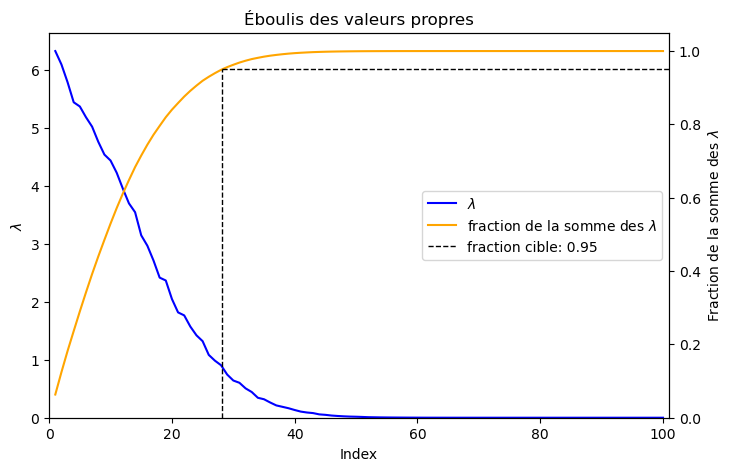

In [8]:
scree_plot(p, lbd)

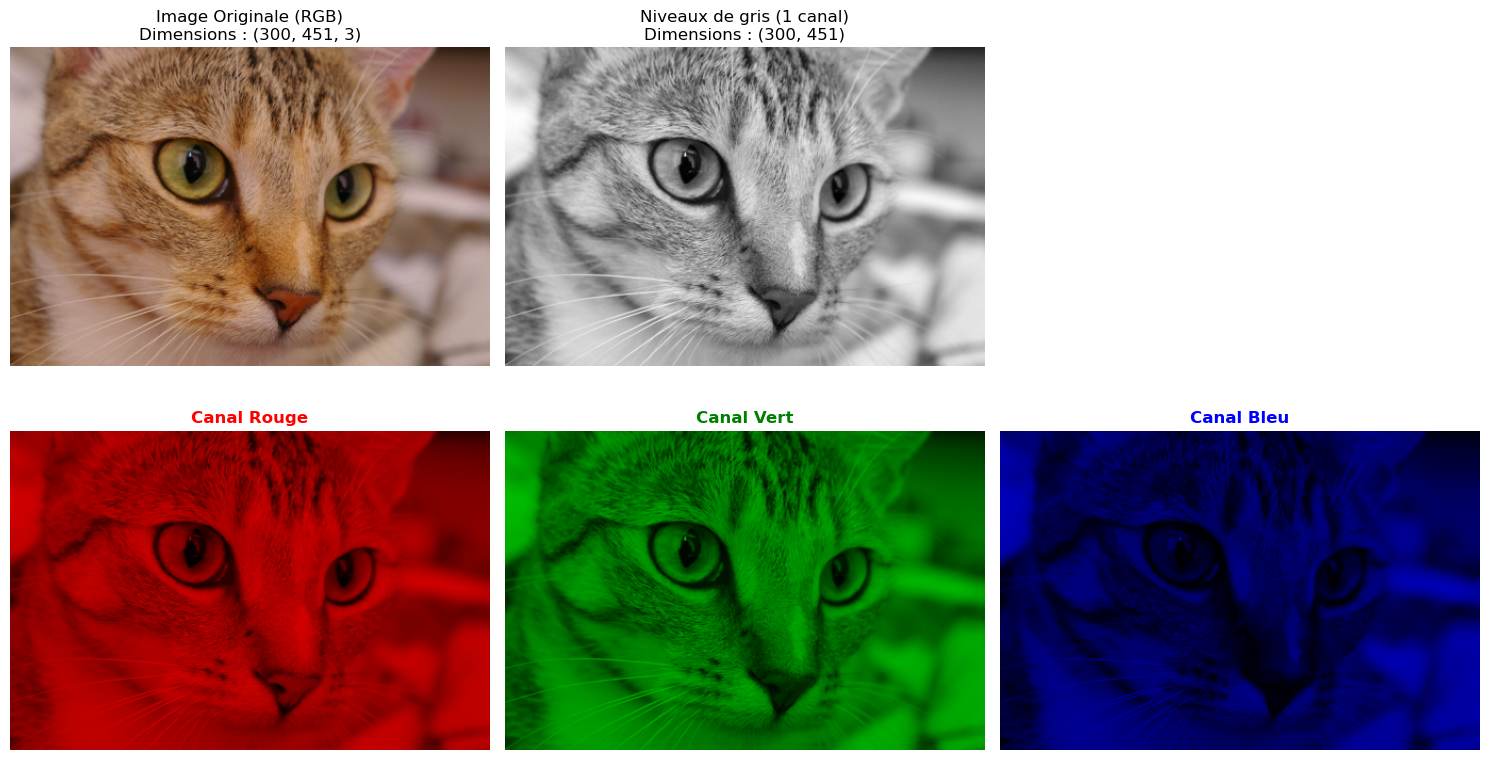

In [9]:
# Chat Chelsea ou Logo université
img_rgb = data.chelsea() 
# img_rgb = plt.imread("../Images/logo-UT.png")

# Conversion en niveaux de gris
img_gray = rgb2gray(img_rgb)

# Séparation des canaux RGB ---
# On crée des tenseurs remplis de zéros ayant la même forme que l'image originale
img_r = np.zeros_like(img_rgb)
img_g = np.zeros_like(img_rgb)
img_b = np.zeros_like(img_rgb)

# On injecte uniquement l'information du canal correspondant (0=R, 1=G, 2=B)
img_r[:, :, 0] = img_rgb[:, :, 0]
img_g[:, :, 1] = img_rgb[:, :, 1]
img_b[:, :, 2] = img_rgb[:, :, 2]

# 4. Affichage du résultat ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Ligne du haut : Originale et Niveaux de gris
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"Image Originale (RGB)\nDimensions : {img_rgb.shape}", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(img_gray, cmap='gray')
axes[0, 1].set_title(f"Niveaux de gris (1 canal)\nDimensions : {img_gray.shape}", fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].axis('off')

# Ligne du bas : Les 3 canaux isolés
axes[1, 0].imshow(img_r)
axes[1, 0].set_title("Canal Rouge", fontsize=12, color='red', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_g)
axes[1, 1].set_title("Canal Vert", fontsize=12, color='green', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_b)
axes[1, 2].set_title("Canal Bleu", fontsize=12, color='blue', fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()